# Project AegisSilicon — EDA & Model Training

## Setup — Imports & Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Sklearn — preprocessing & splitting
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# Sklearn — regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Sklearn — classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Sklearn — anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

# Gradient boosting
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

print("✅ Libraries loaded")

✅ Libraries loaded


---
## Step 1 — Load Dataset & Drop Leakage Columns

Three columns (`anomaly_score`, `is_corrupted`, `psi_value`) are model outputs computed *after* the fact — including them would let the model "cheat" at prediction. We drop them before any analysis.

In [11]:
df = pd.read_csv("/content/aegis_silicon_telemetry_200k_17C.csv", parse_dates=["timestamp"])
df = df.drop("Unnamed: 0",axis=1)

print(f"Shape : {df.shape}")
print(f"\nColumns ({df.shape[1]}):")
for c in df.columns:
    print(f"  {c:<30} {df[c].dtype}")

Shape : (200000, 18)

Columns (18):
  timestamp                      datetime64[ns]
  node_id                        object
  batch_id                       int64
  expected_result                float64
  actual_result                  float64
  deviation                      float64
  pct_deviation                  float64
  z_score                        float64
  temperature_celsius            float64
  power_draw_watts               float64
  memory_util_pct                float64
  compute_util_pct               float64
  ops_per_sec                    int64
  tensor_core_errors             int64
  mem_ecc_errors                 int64
  network_latency_ms             float64
  mtbf_hours                     float64
  node_status                    object


---
## Step 2 — Data Quality Check

Before any analysis, confirm the data is clean: no nulls, no duplicate rows, sensible date range.

In [12]:
print("=" * 50)
print("  NULL VALUES")
print("=" * 50)
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No null values found")

print(f"\n  Total nulls     : {df.isnull().sum().sum()}")
print(f"  Duplicate rows  : {df.duplicated().sum()}")
print(f"  Date range      : {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"  Unique nodes    : {df['node_id'].nunique()}")
print(f"  Node statuses   : {df['node_status'].value_counts().to_dict()}")

  NULL VALUES
✅ No null values found

  Total nulls     : 0
  Duplicate rows  : 0
  Date range      : 2026-06-01 00:00:00  →  2026-06-03 07:33:19
  Unique nodes    : 20
  Node statuses   : {'HEALTHY': 194017, 'DEGRADED': 5983}


---
## Step 3 — Class Balance

Checking how many HEALTHY vs DEGRADED rows exist. A large imbalance means a model can score high accuracy just by predicting the majority class — so we need metrics like F1 and ROC-AUC instead.

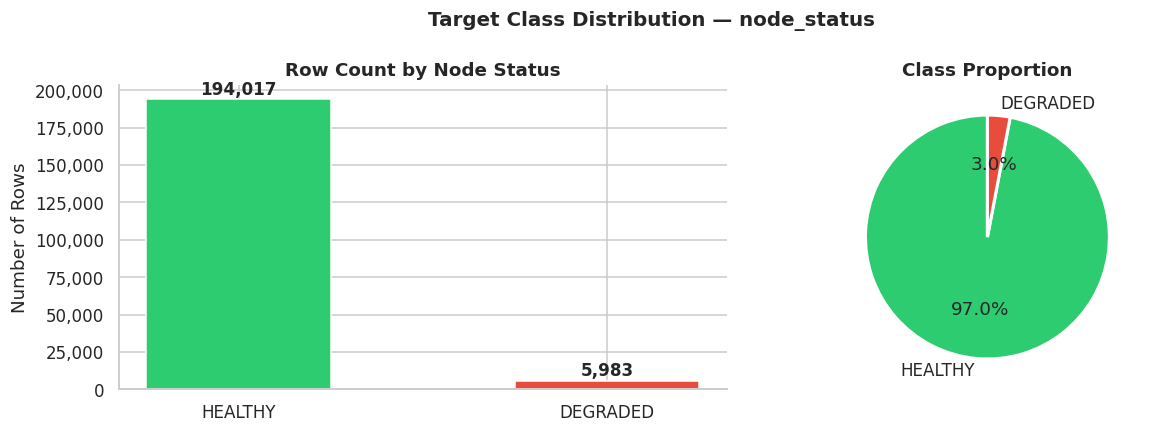

  HEALTHY  : 194,017 rows  (97.0%)
  DEGRADED : 5,983 rows  (3.0%)

  Imbalance ratio  : 32.4x
  ⚠️  Use class_weight='balanced' or scale_pos_weight in models to handle this.


In [13]:
counts = df["node_status"].value_counts()
pct    = df["node_status"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — row counts
palette = {"HEALTHY": "#2ecc71", "DEGRADED": "#e74c3c"}
bars = axes[0].bar(counts.index, counts.values,
                   color=[palette[s] for s in counts.index], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0].set_title("Row Count by Node Status", fontweight="bold")
axes[0].set_ylabel("Number of Rows")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie chart — proportion
axes[1].pie(counts.values, labels=counts.index,
            colors=[palette[s] for s in counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion", fontweight="bold")

plt.suptitle("Target Class Distribution — node_status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"  HEALTHY  : {counts['HEALTHY']:,} rows  ({pct['HEALTHY']:.1f}%)")
print(f"  DEGRADED : {counts['DEGRADED']:,} rows  ({pct['DEGRADED']:.1f}%)")
print(f"\n  Imbalance ratio  : {counts.max() / counts.min():.1f}x")
print("  ⚠️  Use class_weight='balanced' or scale_pos_weight in models to handle this.")

---
## Step 4 — Descriptive Statistics

Summary statistics plus skewness and kurtosis for each numeric feature.
- **Skewness > 1 or < -1**: distribution is noticeably lopsided → may need log-transform
- **Kurtosis > 3**: heavy tails, more extreme outliers than a normal distribution

In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
desc = df[num_cols].describe().T
desc["skewness"] = df[num_cols].skew().round(3)
desc["kurtosis"] = df[num_cols].kurt().round(3)
desc.round(4)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
batch_id,200000.0,9999.5000,5773.5171,0.0000,4999.7500,9999.5000,14999.2500,19999.0000,-0.000,-1.200
expected_result,200000.0,156.1169,7.8961,124.8315,150.7403,156.0276,161.3804,191.8970,0.077,0.005
actual_result,200000.0,156.1202,7.9200,124.8315,150.7384,156.0271,161.3810,236.9908,0.122,0.405
deviation,200000.0,0.0033,0.5838,-32.0000,0.0000,0.0000,0.0000,64.0000,84.612,9874.633
pct_deviation,200000.0,0.0021,0.3631,-19.9463,0.0000,0.0000,0.0000,42.8596,84.332,9816.296
z_score,200000.0,0.0028,1.1141,-6.3843,-0.7303,-0.0119,0.7141,16.7417,0.161,1.185
temperature_celsius,200000.0,63.0514,4.5653,49.7500,59.1700,63.3600,66.8800,78.2300,-0.120,-1.005
power_draw_watts,200000.0,312.9961,21.1919,249.5900,296.0000,311.4300,328.4000,382.5700,0.255,-0.725
memory_util_pct,200000.0,55.0007,11.9930,0.0000,46.8900,54.9900,63.1100,100.0000,0.003,-0.016
compute_util_pct,200000.0,74.6983,14.3846,2.7900,64.8900,75.0000,85.1200,100.0000,-0.231,-0.328


---
## Step 5 — Z-Score Distribution: HEALTHY vs DEGRADED

Z-score measures how far a reading is from its expected value (in standard deviations). Readings above **2.0** are flagged as potentially anomalous. We expect DEGRADED nodes to have higher, more spread-out Z-scores.

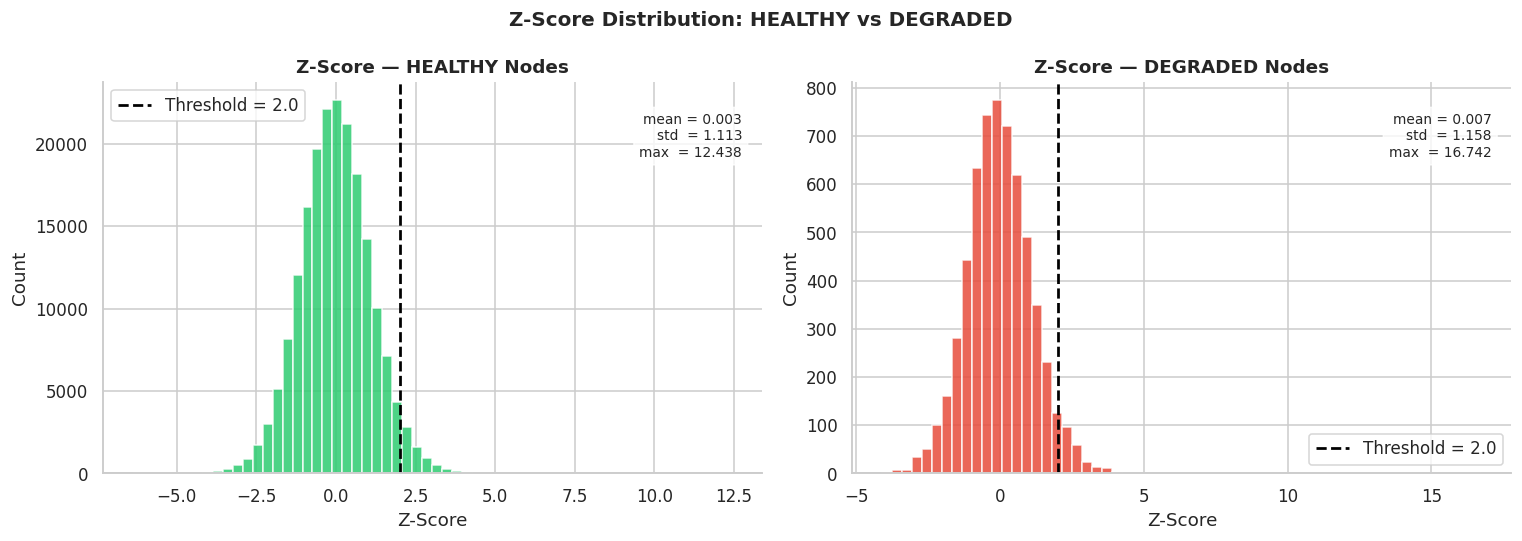

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
status_cfg = [
    ("HEALTHY", "#2ecc71", axes[0]),
    ("DEGRADED", "#e74c3c", axes[1]),
]

for status, color, ax in status_cfg:
    sub = df[df["node_status"] == status]["z_score"]
    ax.hist(sub, bins=60, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(2.0, color="black", linestyle="--", linewidth=1.8, label="Threshold = 2.0")
    ax.set_title(f"Z-Score — {status} Nodes", fontweight="bold")
    ax.set_xlabel("Z-Score")
    ax.set_ylabel("Count")
    ax.legend()

    # Annotate key stats using a multi-line triple-quoted f-string
    ax.text(0.97, 0.92, f"""mean = {sub.mean():.3f}
std  = {sub.std():.3f}
max  = {sub.max():.3f}""",
            transform=ax.transAxes, ha="right", va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8), fontsize=9)

plt.suptitle("Z-Score Distribution: HEALTHY vs DEGRADED", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 6 — Deviation Analysis

Deviation = actual reading − expected reading. Ideally this is near zero. DEGRADED nodes should show larger, more consistent deviations in one direction.

**Left plot** — KDE (smoothed distribution): shows shape differences between the two groups.  
**Right plot** — Average absolute deviation per node: reveals which specific nodes are misbehaving most.

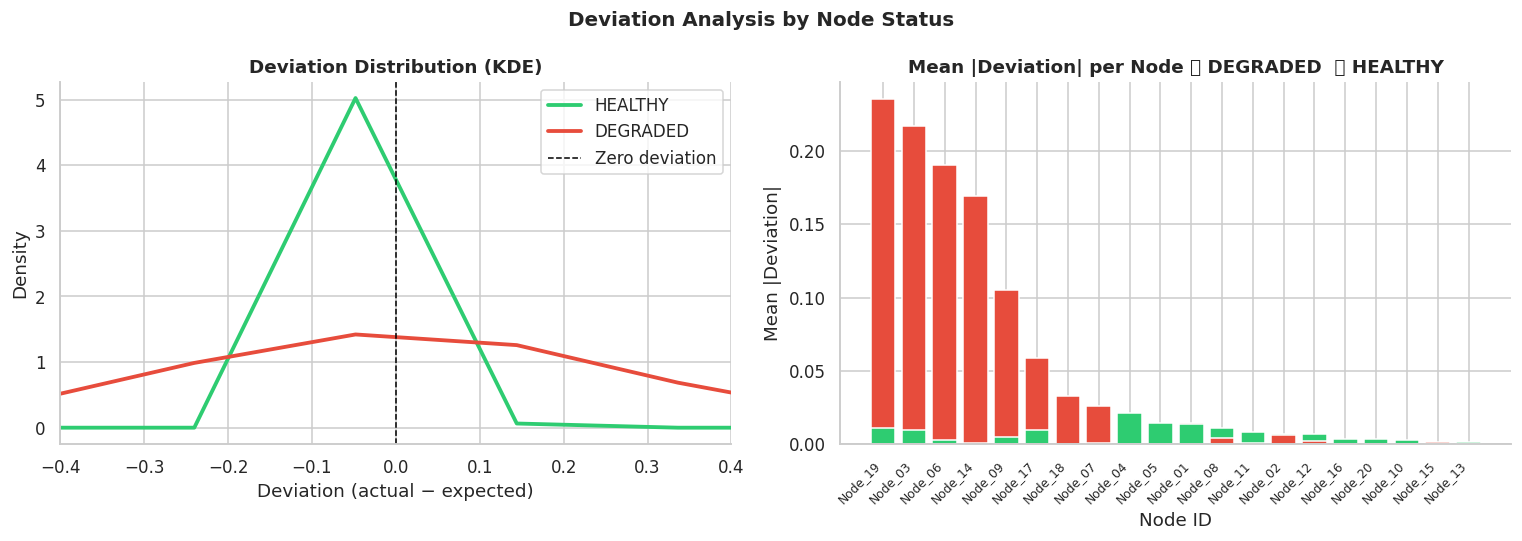

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. KDE by status
for status, color in [("HEALTHY", "#2ecc71"), ("DEGRADED", "#e74c3c")]:
    df[df["node_status"] == status]["deviation"].plot.kde(
        ax=axes[0], color=color, linewidth=2.5, label=status
    )
axes[0].set_xlim(-0.4, 0.4)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", label="Zero deviation")
axes[0].set_title("Deviation Distribution (KDE)", fontweight="bold")
axes[0].set_xlabel("Deviation (actual − expected)")
axes[0].legend()

# 2. Mean |deviation| per node
avg_dev = (df.groupby(["node_id", "node_status"])["deviation"]
             .apply(lambda x: x.abs().mean())
             .reset_index(name="mean_abs_deviation")
             .sort_values("mean_abs_deviation", ascending=False))

bar_colors = ["#e74c3c" if s == "DEGRADED" else "#2ecc71" for s in avg_dev["node_status"]]
axes[1].bar(avg_dev["node_id"], avg_dev["mean_abs_deviation"], color=bar_colors, edgecolor="white")

# Fixed the multi-line string issue here using a single-line clean string
axes[1].set_title("Mean |Deviation| per Node 🔴 DEGRADED  🟢 HEALTHY", fontweight="bold")
axes[1].set_xlabel("Node ID")
axes[1].set_ylabel("Mean |Deviation|")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.suptitle("Deviation Analysis by Node Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 7 — Feature Boxplots: HEALTHY vs DEGRADED

Boxplots show the median (centre line), interquartile range (box), and outliers (dots). A clear separation between HEALTHY and DEGRADED boxes means the feature will be useful for classification.

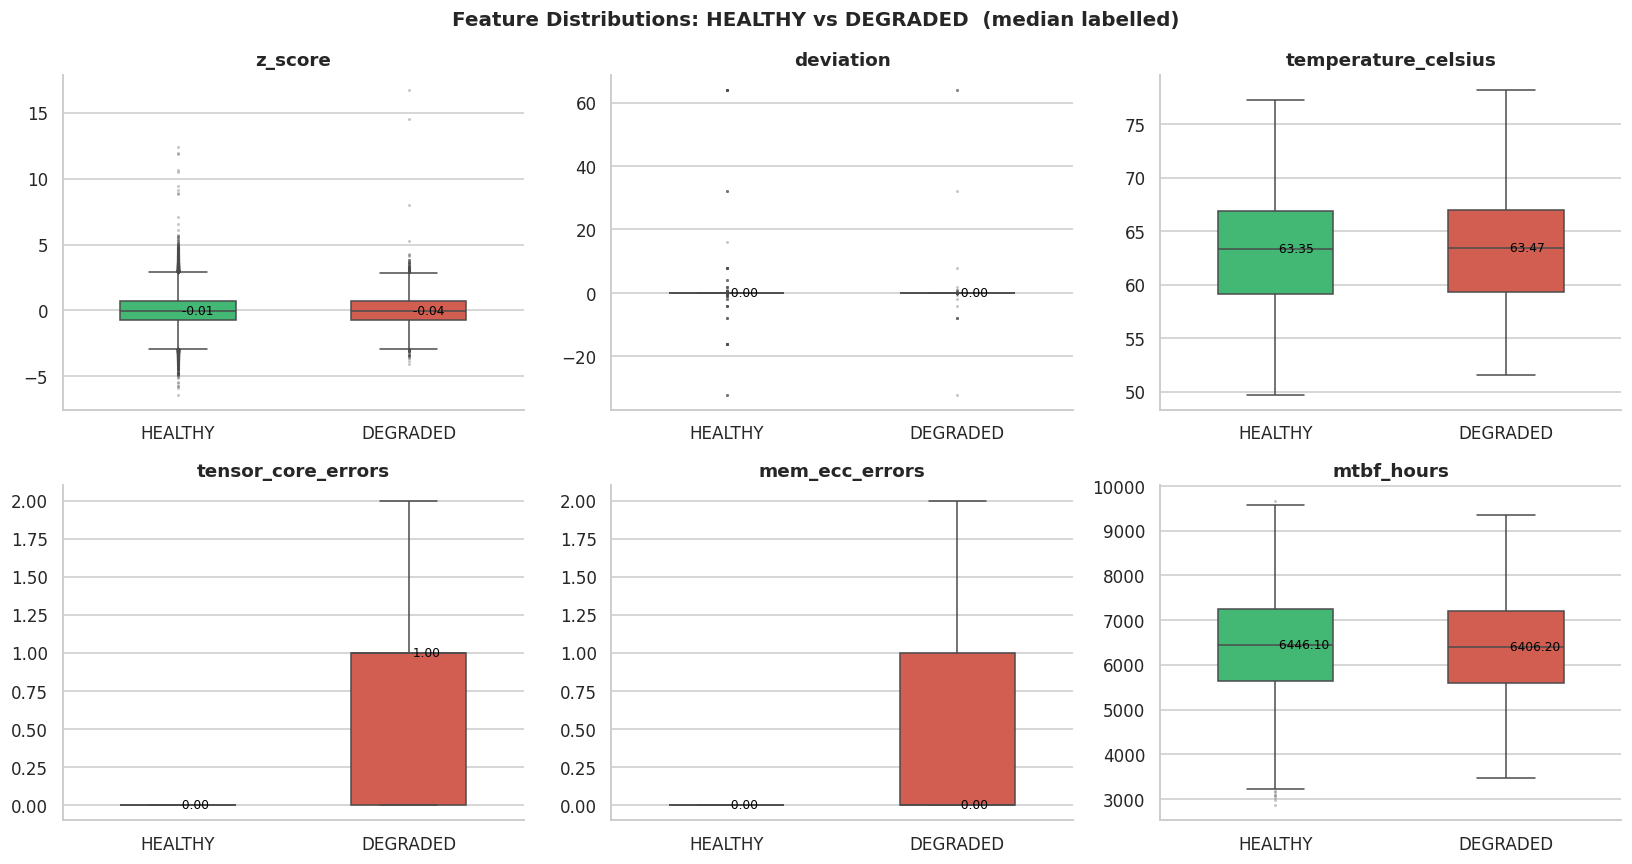

In [19]:
features = ["z_score", "deviation", "temperature_celsius",
            "tensor_core_errors", "mem_ecc_errors", "mtbf_hours"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = {"HEALTHY": "#2ecc71", "DEGRADED": "#e74c3c"}

for i, feat in enumerate(features):
    sns.boxplot(data=df, x="node_status", y=feat,
                palette=palette, ax=axes[i], width=0.5,
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(feat, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # Add median labels
    for j, status in enumerate(["HEALTHY", "DEGRADED"]):
        med = df[df["node_status"] == status][feat].median()
        axes[i].text(j, med, f" {med:.2f}", va="center", fontsize=8, color="black")

plt.suptitle("Feature Distributions: HEALTHY vs DEGRADED  (median labelled)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 8 — Correlation Heatmap

Shows the pairwise Pearson correlation between numeric features. Values close to **+1** or **-1** indicate strong relationships; close to **0** means little linear relationship.

Key things to look for:
- Features strongly correlated with `deviation` → good predictors
- Features highly correlated with *each other* → multicollinearity risk in linear models

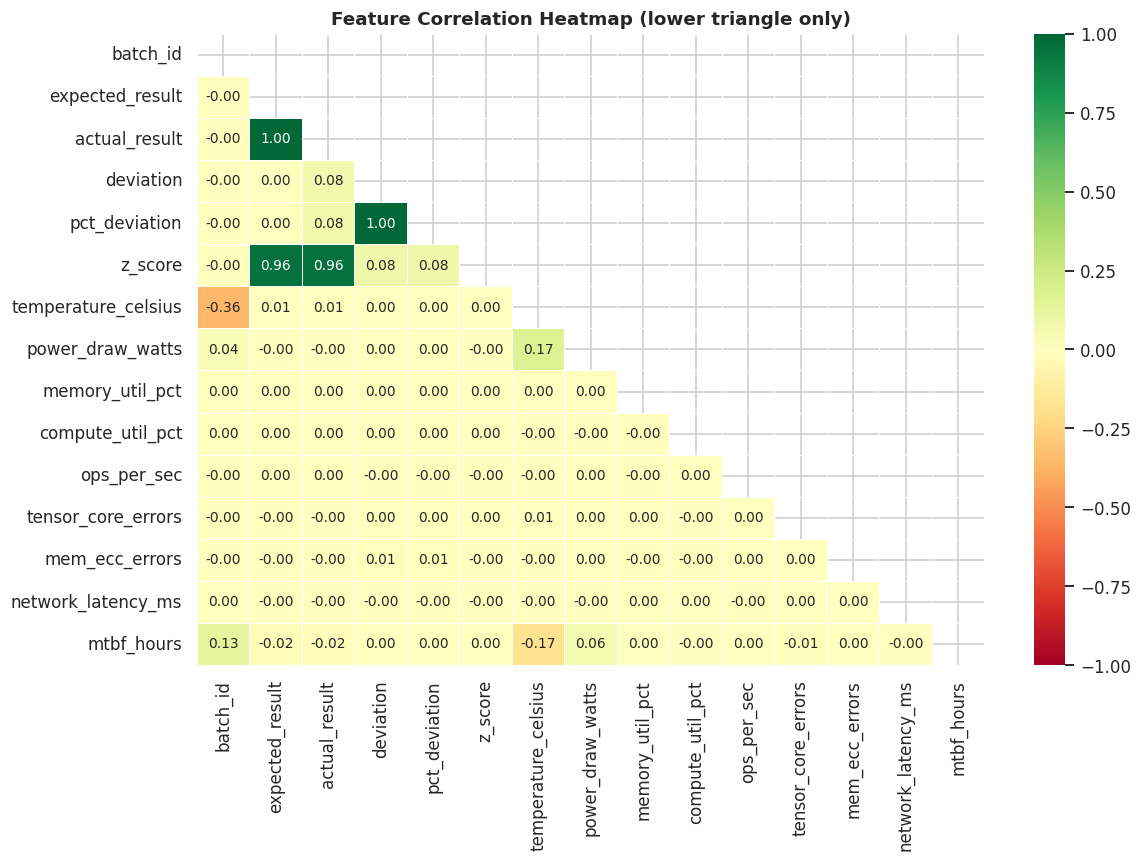

Top correlations with DEVIATION:
  pct_deviation                +███████████████████   +0.9989
  z_score                      +█                     +0.0823
  actual_result                +█                     +0.0778
  mem_ecc_errors               +                      +0.0081
  batch_id                     -                      -0.0049
  temperature_celsius          +                      +0.0047
  expected_result              +                      +0.0041
  tensor_core_errors           +                      +0.0030
  compute_util_pct             +                      +0.0016
  power_draw_watts             +                      +0.0010
  mtbf_hours                   +                      +0.0008
  network_latency_ms           -                      -0.0006
  memory_util_pct              +                      +0.0001
  ops_per_sec                  -                      -0.0001


In [20]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show only lower triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 9}, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Heatmap (lower triangle only)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top correlations with DEVIATION:")
top = corr["deviation"].drop("deviation").sort_values(key=abs, ascending=False)
for feat, val in top.items():
    bar = "█" * int(abs(val) * 20)
    direction = "+" if val > 0 else "-"
    print(f"  {feat:<28} {direction}{bar:<20}  {val:+.4f}")

---
## Step 9 — Z-Score Over Time (3 Nodes)

Resampling to 10-minute averages to reduce noise. This reveals whether degradation is sudden (spike) or gradual (rising trend). The red dashed line at Z = 2.0 is the anomaly threshold.

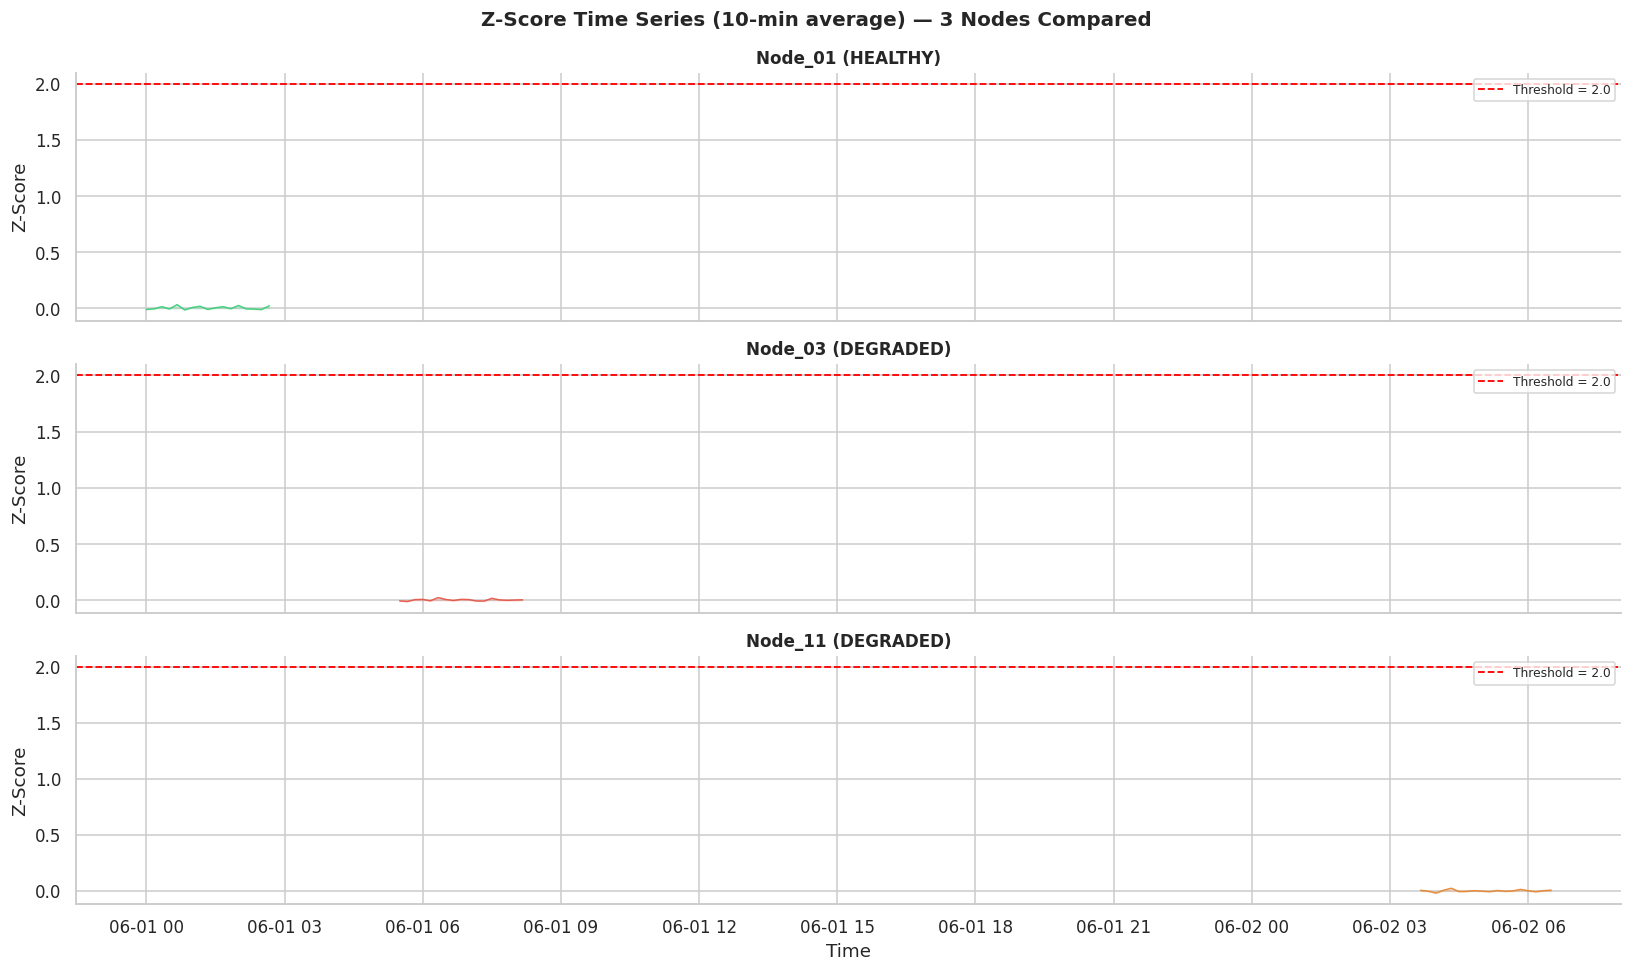

In [21]:
nodes  = ["Node_01", "Node_03", "Node_11"]
labels = ["Node_01 (HEALTHY)", "Node_03 (DEGRADED)", "Node_11 (DEGRADED)"]
colors = ["#2ecc71", "#e74c3c", "#e67e22"]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, node, color, label in zip(axes, nodes, colors, labels):
    sub = (df[df["node_id"] == node]
           .set_index("timestamp")["z_score"]
           .resample("10min").mean())
    ax.plot(sub.index, sub.values, color=color, linewidth=1.0, alpha=0.85)
    ax.fill_between(sub.index, sub.values, alpha=0.12, color=color)
    ax.axhline(2.0, color="red", linestyle="--", linewidth=1.2, label="Threshold = 2.0")
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylabel("Z-Score")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")
plt.suptitle("Z-Score Time Series (10-min average) — 3 Nodes Compared",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
---
# Part 2 — Model Training



## Feature Preparation

Scale all numeric features so that models treating distance or magnitude (Ridge, KNN, SVM) aren't biased by features with larger ranges.

In [23]:
FEATURES = [c for c in num_cols if c not in ["deviation"]]

X = df[FEATURES].values
y_reg = df["deviation"]                             # Regression target
y_cls = LabelEncoder().fit_transform(df["node_status"])  # Classification target (0=HEALTHY, 1=DEGRADED)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X_scaled, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Features     : {len(FEATURES)}")
print(f"Features used: {FEATURES}")

Training set : 160,000 rows
Test set     : 40,000 rows
Features     : 14
Features used: ['batch_id', 'expected_result', 'actual_result', 'pct_deviation', 'z_score', 'temperature_celsius', 'power_draw_watts', 'memory_util_pct', 'compute_util_pct', 'ops_per_sec', 'tensor_core_errors', 'mem_ecc_errors', 'network_latency_ms', 'mtbf_hours']


---
# Part A — Regression Models
**Target: `deviation` (continuous)**

## A1 — OLS Regression (statsmodels)

OLS (Ordinary Least Squares) is the classical statistical regression. It gives us **coefficients with p-values** so we can see which features are statistically significant predictors of deviation — not just whether the model is accurate, but *why*.

In [24]:
X_ols = sm.add_constant(X_scaled_df)
ols   = sm.OLS(y_reg, X_ols).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              deviation   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.853e+30
Date:                Sun, 28 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:23:43   Log-Likelihood:             5.9098e+06
No. Observations:              200000   AIC:                        -1.182e+07
Df Residuals:                  199985   BIC:                        -1.182e+07
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0033   7

## A2 — Comparing Regression Models

We test a range of model types from simple linear to tree-based ensembles. This gives a picture of how much we gain from complexity.

- **R²** — proportion of variance explained (higher = better, max 1.0)
- **RMSE** — root mean squared error in the same units as `deviation` (lower = better)

In [25]:
reg_models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge  (α=1.0)"     : Ridge(alpha=1.0),
    "Lasso  (α=0.001)"   : Lasso(alpha=0.001, max_iter=5000),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost"            : XGBRegressor(n_estimators=100, tree_method="hist", random_state=42, verbosity=0),
    "LightGBM"           : LGBMRegressor(n_estimators=100, random_state=42),
}

reg_results = []
print(f"{'Model':<22} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("-" * 55)
for name, model in reg_models.items():
    model.fit(X_train, yr_train)
    pred = model.predict(X_test)
    r2   = r2_score(yr_test, pred)
    mae  = mean_absolute_error(yr_test, pred)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    reg_results.append({"Model": name, "R²": round(r2,4), "MAE": round(mae,6), "RMSE": round(rmse,6)})
    print(f"{name:<22} {r2:>8.4f} {mae:>10.6f} {rmse:>10.6f}")

reg_df = pd.DataFrame(reg_results).sort_values("R²", ascending=False)
print(f"\n🏆 Best: {reg_df.iloc[0]['Model']}  (R²={reg_df.iloc[0]['R²']})")

Model                        R²        MAE       RMSE
-------------------------------------------------------
Linear Regression        1.0000   0.000000   0.000000
Ridge  (α=1.0)           0.9993   0.000325   0.014755
Lasso  (α=0.001)         0.9975   0.000274   0.028704
Decision Tree            0.9999   0.000116   0.004794
Random Forest            0.9996   0.000160   0.011409
Gradient Boosting        1.0000   0.000002   0.000068
XGBoost                  0.6750   0.003204   0.326503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031847 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3068
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 14
[LightGBM] [Info] Start training from score 0.003270
LightGBM                 0.8037   0.005193   0.253750

🏆 Best: Linear Regression  (R²=1.0)


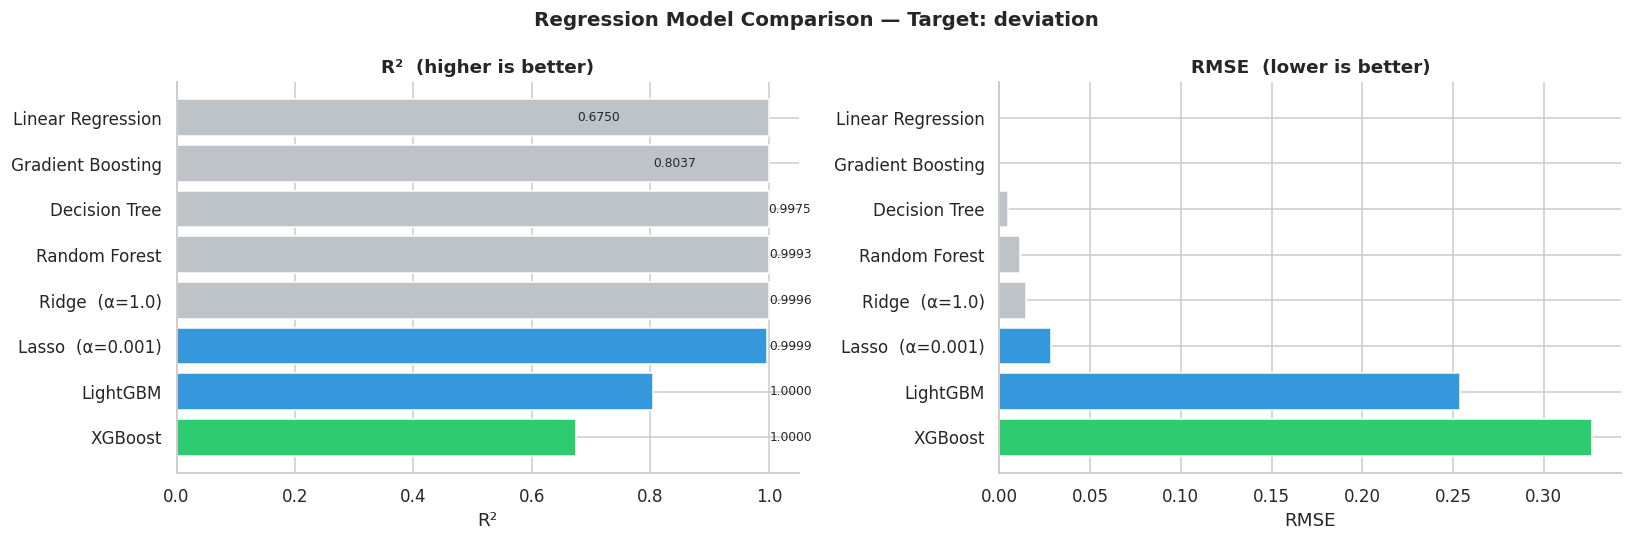

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

n = len(reg_df)
colors = ["#2ecc71" if i == 0 else "#3498db" if i < 3 else "#bdc3c7" for i in range(n)]

axes[0].barh(reg_df["Model"], reg_df["R²"], color=colors[::-1], edgecolor="white")
axes[0].set_title("R²  (higher is better)", fontweight="bold")
axes[0].set_xlabel("R²")
axes[0].invert_yaxis()
for i, (val, label) in enumerate(zip(reg_df["R²"][::-1], reg_df["Model"][::-1])):
    axes[0].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

axes[1].barh(reg_df["Model"], reg_df["RMSE"], color=colors[::-1], edgecolor="white")
axes[1].set_title("RMSE  (lower is better)", fontweight="bold")
axes[1].set_xlabel("RMSE")
axes[1].invert_yaxis()

plt.suptitle("Regression Model Comparison — Target: deviation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## A3 — Best Model: Actual vs Predicted & Residuals

**Actual vs Predicted** — points should hug the red diagonal (perfect-fit line). Scatter away from it shows prediction error.

**Residual histogram** — residuals (actual − predicted) should be roughly bell-shaped and centred on 0. Skew or a second peak suggests systematic bias.

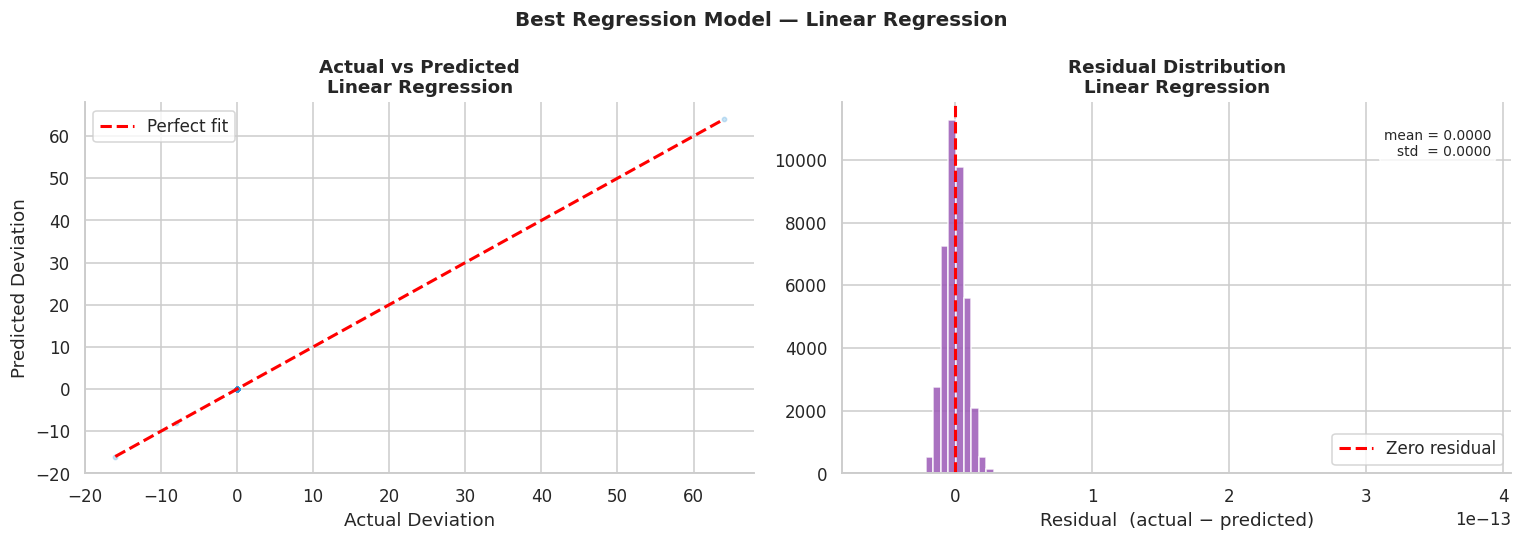

R² = 1.0  |  RMSE = 0.0


In [27]:
best_reg_name  = reg_df.iloc[0]["Model"]
best_reg_model = reg_models[best_reg_name]
best_reg_pred  = best_reg_model.predict(X_test)
residuals      = yr_test.values - best_reg_pred

idx = np.random.choice(len(yr_test), min(3000, len(yr_test)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted
axes[0].scatter(yr_test.iloc[idx], best_reg_pred[idx],
                alpha=0.25, s=8, color="#3498db")
lims = [min(yr_test.min(), best_reg_pred.min()), max(yr_test.max(), best_reg_pred.max())]
axes[0].plot(lims, lims, color="red", linewidth=2, linestyle="--", label="Perfect fit")
axes[0].set_title(f"Actual vs Predicted\n{best_reg_name}", fontweight="bold")
axes[0].set_xlabel("Actual Deviation")
axes[0].set_ylabel("Predicted Deviation")
axes[0].legend()

# Residuals
axes[1].hist(residuals, bins=80, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linewidth=2, linestyle="--", label="Zero residual")
axes[1].set_title(f"Residual Distribution\n{best_reg_name}", fontweight="bold")
axes[1].set_xlabel("Residual  (actual − predicted)")
axes[1].legend()
axes[1].text(0.97, 0.93,
             f"mean = {residuals.mean():.4f}\nstd  = {residuals.std():.4f}",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8), fontsize=9)

plt.suptitle(f"Best Regression Model — {best_reg_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"R² = {reg_df.iloc[0]['R²']}  |  RMSE = {reg_df.iloc[0]['RMSE']}")

## A4 — OLS Residual Diagnostics

The four-plot diagnostic suite for OLS:
1. **Residuals vs Fitted** — should show no pattern (random scatter around 0)
2. **Residual histogram** — should be bell-shaped and centred at 0
3. **Q-Q Plot** — points close to the line = residuals are approximately normal
4. **Scale-Location** — should be a flat horizontal band (constant variance)

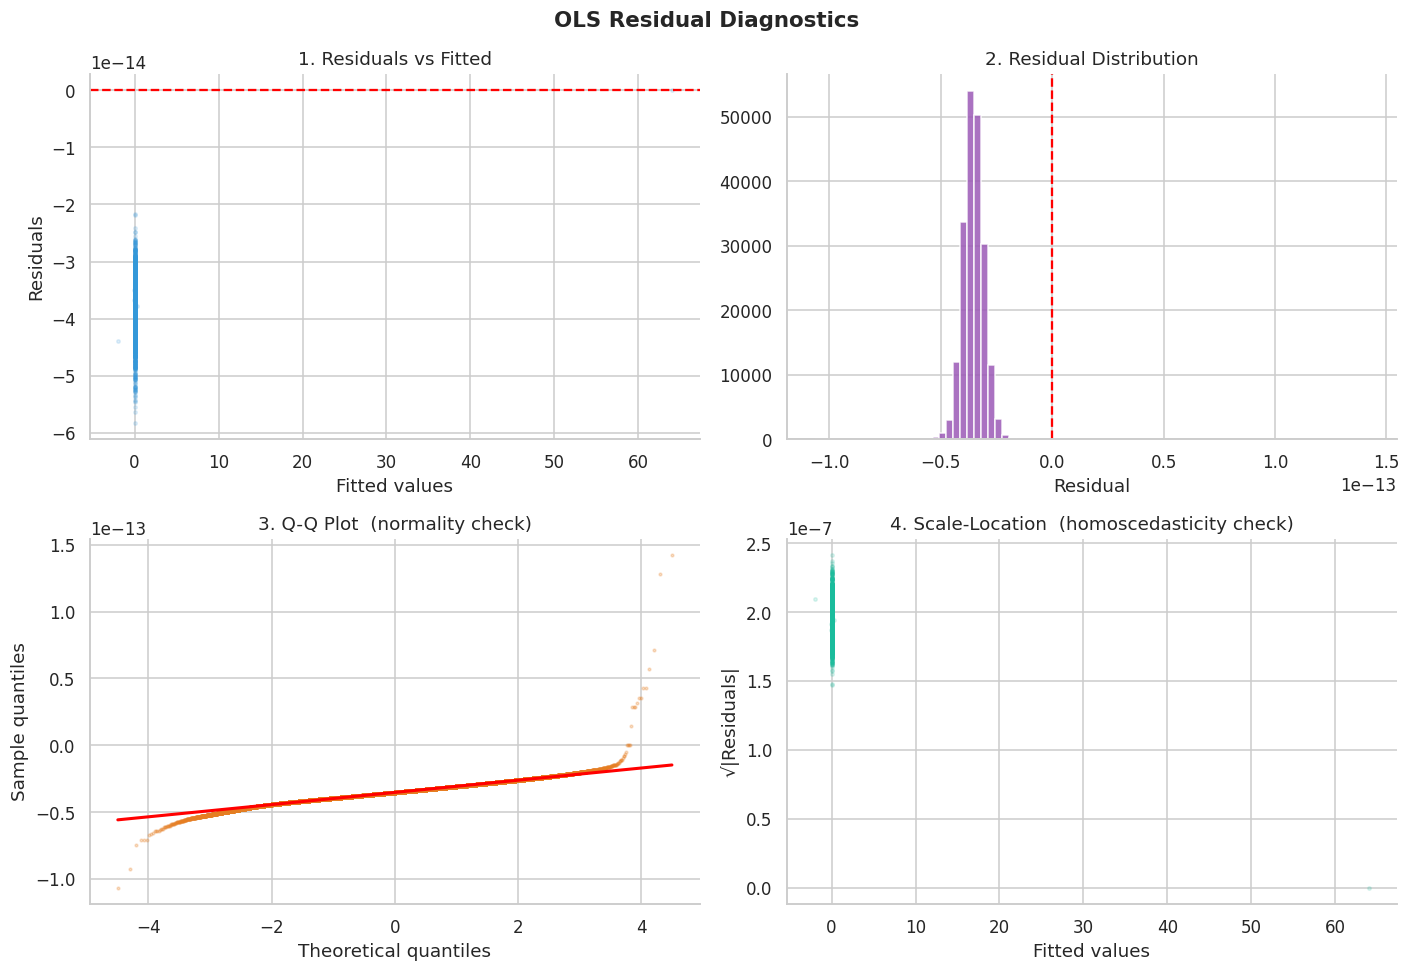

In [28]:
res = ols.resid
fit = ols.fittedvalues
n_plot = 5000  # subsample for speed

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("OLS Residual Diagnostics", fontsize=14, fontweight="bold")

# 1. Residuals vs Fitted
axes[0, 0].scatter(fit[:n_plot], res[:n_plot], alpha=0.15, s=5, color="#3498db")
axes[0, 0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0, 0].set_title("1. Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# 2. Residual histogram
axes[0, 1].hist(res, bins=80, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[0, 1].set_title("2. Residual Distribution")
axes[0, 1].set_xlabel("Residual")

# 3. Q-Q plot
(osm, osr), (slope, intercept, _) = stats.probplot(res, dist="norm")
axes[1, 0].scatter(osm, osr, s=3, alpha=0.25, color="#e67e22")
axes[1, 0].plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=2)
axes[1, 0].set_title("3. Q-Q Plot  (normality check)")
axes[1, 0].set_xlabel("Theoretical quantiles")
axes[1, 0].set_ylabel("Sample quantiles")

# 4. Scale-Location
axes[1, 1].scatter(fit[:n_plot], np.sqrt(np.abs(res[:n_plot])), alpha=0.15, s=5, color="#1abc9c")
axes[1, 1].set_title("4. Scale-Location  (homoscedasticity check)")
axes[1, 1].set_xlabel("Fitted values")
axes[1, 1].set_ylabel("√|Residuals|")

plt.tight_layout()
plt.show()

---
# Part B — Classification Models
**Target: `node_status` — HEALTHY (0) vs DEGRADED (1)**

## B1 — Comparing Classification Models

Key metrics:
- **ROC-AUC** — how well the model separates the two classes (0.5 = random guessing, 1.0 = perfect)
- **F1 Score** — harmonic mean of precision and recall; important for imbalanced classes
- **Accuracy** — overall correctness, but misleading when classes are unbalanced

In [30]:
cls_models = {
    "Logistic Regression"  : LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
    "Decision Tree (d=5)"  : DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "Random Forest"        : RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "AdaBoost"             : AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost"              : XGBClassifier(n_estimators=100, scale_pos_weight=3, tree_method="hist", random_state=42, verbosity=0),
    "LightGBM"             : LGBMClassifier(n_estimators=100, class_weight="balanced", random_state=42, verbose=-1),
    "Naive Bayes"          : GaussianNB(),
}

cls_results = []
print(f"{'Model':<24} {'ROC-AUC':>9} {'F1':>7} {'Accuracy':>10}")
print("-" * 55)
for name, model in cls_models.items():
    model.fit(X_train, yc_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(yc_test, prob)
    f1   = f1_score(yc_test, pred)
    acc  = accuracy_score(yc_test, pred)
    cls_results.append({"Model": name, "ROC-AUC": round(auc,4), "F1": round(f1,4), "Accuracy": round(acc,4)})
    print(f"{name:<24} {auc:>9.4f} {f1:>7.4f} {acc:>10.4f}")

cls_df = pd.DataFrame(cls_results).sort_values("ROC-AUC", ascending=False)
print(f"\n Best: {cls_df.iloc[0]['Model']}  (AUC={cls_df.iloc[0]['ROC-AUC']})")

Model                      ROC-AUC      F1   Accuracy
-------------------------------------------------------
Logistic Regression         1.0000  1.0000     1.0000
Decision Tree (d=5)         0.9996  1.0000     1.0000
Random Forest               1.0000  1.0000     1.0000
Gradient Boosting           0.9996  1.0000     1.0000
AdaBoost                    0.9996  1.0000     1.0000
XGBoost                     0.9999  1.0000     1.0000
LightGBM                    0.9996  1.0000     1.0000
Naive Bayes                 1.0000  0.9999     0.9999

 Best: Logistic Regression  (AUC=1.0)


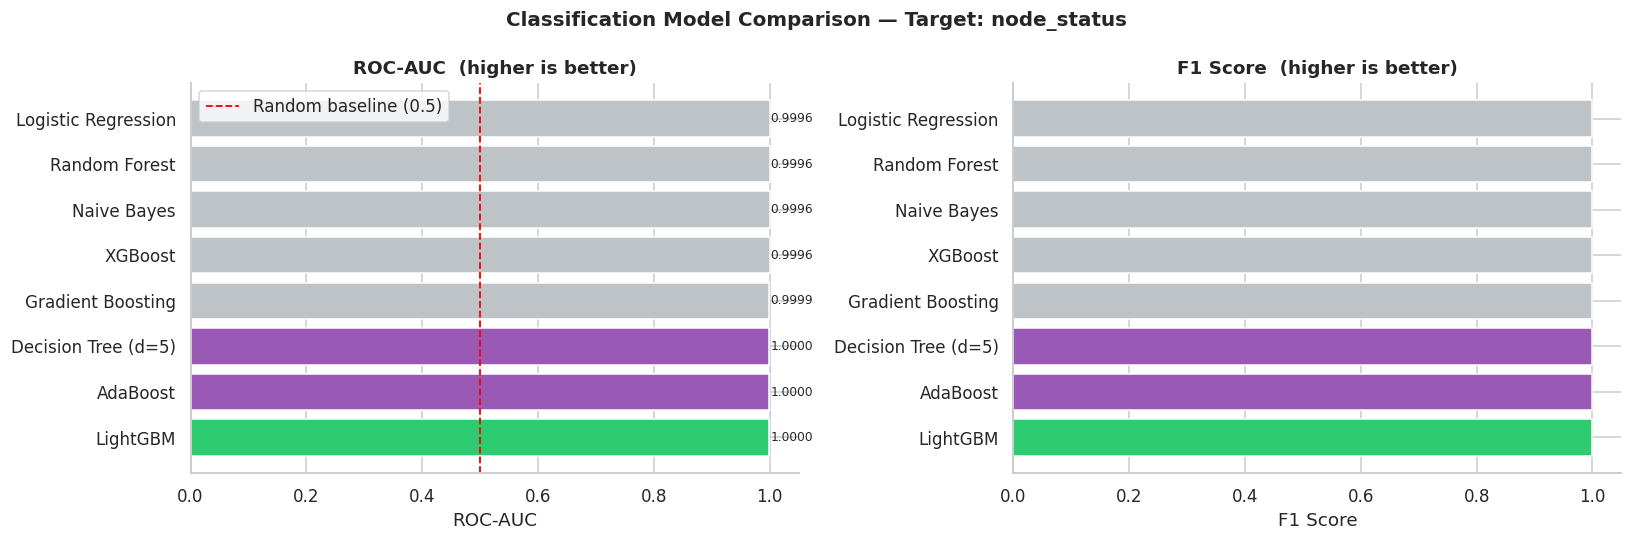

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
n = len(cls_df)
colors = ["#2ecc71" if i == 0 else "#9b59b6" if i < 3 else "#bdc3c7" for i in range(n)]

axes[0].barh(cls_df["Model"], cls_df["ROC-AUC"], color=colors[::-1], edgecolor="white")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1.2, label="Random baseline (0.5)")
axes[0].set_title("ROC-AUC  (higher is better)", fontweight="bold")
axes[0].set_xlabel("ROC-AUC")
axes[0].legend()
axes[0].invert_yaxis()
for i, val in enumerate(cls_df["ROC-AUC"][::-1]):
    axes[0].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

axes[1].barh(cls_df["Model"], cls_df["F1"], color=colors[::-1], edgecolor="white")
axes[1].set_title("F1 Score  (higher is better)", fontweight="bold")
axes[1].set_xlabel("F1 Score")
axes[1].invert_yaxis()

plt.suptitle("Classification Model Comparison — Target: node_status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## B2 — ROC Curves

Each curve shows the trade-off between catching real DEGRADED nodes (true positive rate) and falsely flagging HEALTHY ones (false positive rate). A curve hugging the top-left corner is ideal. The diagonal dashed line represents random guessing.

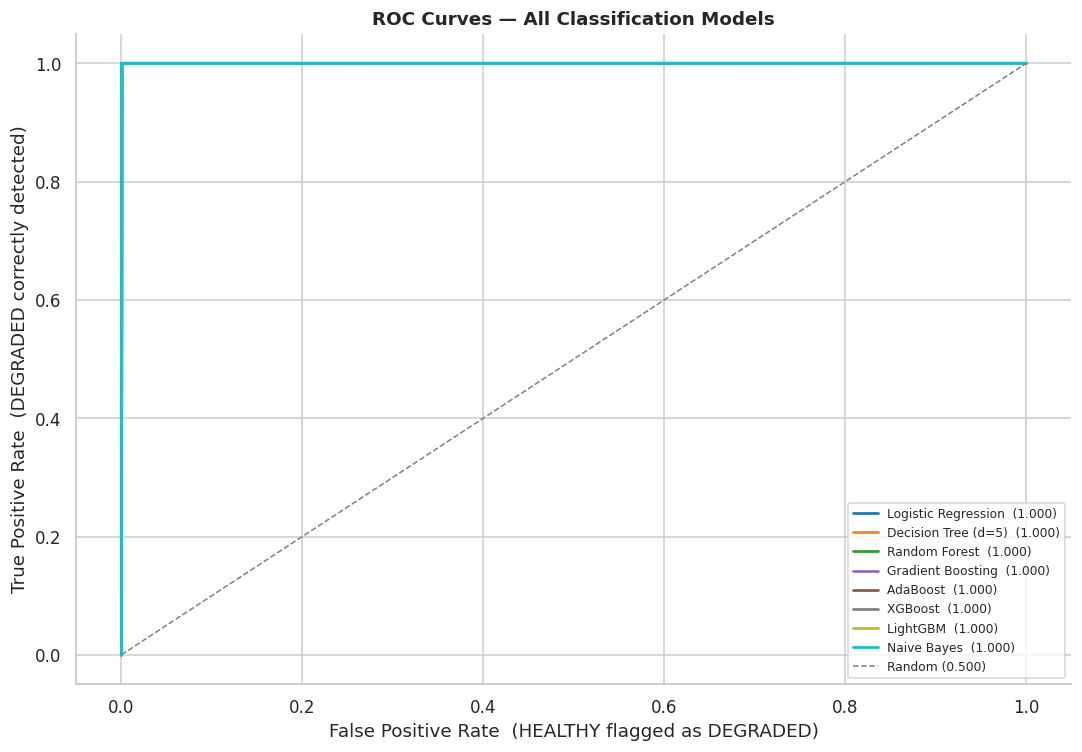

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))
color_cycle = plt.cm.tab10(np.linspace(0, 1, len(cls_models)))

for (name, model), color in zip(cls_models.items(), color_cycle):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, prob)
    auc = roc_auc_score(yc_test, prob)
    ax.plot(fpr, tpr, linewidth=1.8, color=color, label=f"{name}  ({auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random (0.500)")
ax.set_xlabel("False Positive Rate  (HEALTHY flagged as DEGRADED)")
ax.set_ylabel("True Positive Rate  (DEGRADED correctly detected)")
ax.set_title("ROC Curves — All Classification Models", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## B3 — Best Model: Confusion Matrix & Report

The confusion matrix shows:
- **True Positives (DEGRADED correctly caught)** — bottom-right
- **False Negatives (DEGRADED missed)** — bottom-left ← most costly in a hardware monitoring context
- **False Positives (HEALTHY falsely flagged)** — top-right

🏆 Best Classifier: Logistic Regression
   ROC-AUC  : 1.0
   F1 Score : 1.0

              precision    recall  f1-score   support

     HEALTHY       1.00      1.00      1.00      1197
    DEGRADED       1.00      1.00      1.00     38803

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



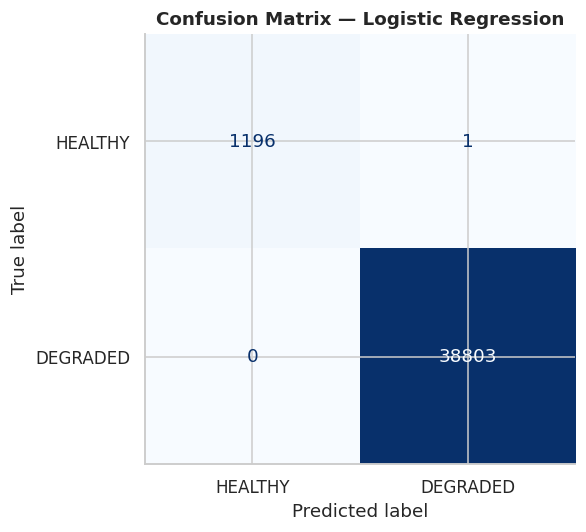

In [33]:
best_cls_name  = cls_df.iloc[0]["Model"]
best_cls_model = cls_models[best_cls_name]
best_cls_pred  = best_cls_model.predict(X_test)

print(f"🏆 Best Classifier: {best_cls_name}")
print(f"   ROC-AUC  : {cls_df.iloc[0]['ROC-AUC']}")
print(f"   F1 Score : {cls_df.iloc[0]['F1']}")
print()
print(classification_report(yc_test, best_cls_pred, target_names=["HEALTHY", "DEGRADED"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(yc_test, best_cls_pred)
ConfusionMatrixDisplay(cm, display_labels=["HEALTHY", "DEGRADED"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_cls_name}", fontweight="bold")
plt.tight_layout()
plt.show()

## B4 — Feature Importance

Random Forest gives us a built-in ranking of how much each sensor contributes to classifying HEALTHY vs DEGRADED. Higher importance = that sensor's readings are more decisive.

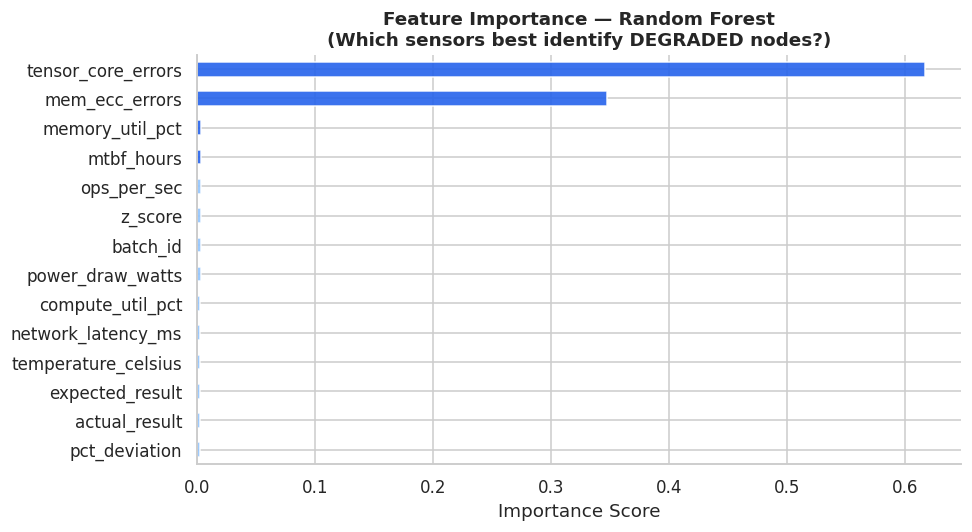

Top 3 most important features:
  tensor_core_errors             0.6170
  mem_ecc_errors                 0.3472
  memory_util_pct                0.0034


In [34]:
rf_clf = cls_models["Random Forest"]
feat_imp = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = ["#2563EB" if v >= feat_imp.quantile(0.75) else "#93c5fd" for v in feat_imp.values]
feat_imp.plot.barh(ax=ax, color=colors_fi, edgecolor="white", alpha=0.9)
ax.set_title("Feature Importance — Random Forest\n(Which sensors best identify DEGRADED nodes?)",
             fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<30} {imp:.4f}")

---
# Part C — Anomaly Detection
**Unsupervised — no labels used — finds unusual node behaviour in raw data**

These models assume most readings are normal and flag the outliers. The `contamination` parameter tells the model what fraction of data to expect as anomalous.

### Isolation Forest Deep Dive

Isolation Forest works by randomly splitting data. Anomalies are isolated faster (fewer splits needed) than normal points. The **anomaly score** reflects this — negative scores indicate anomalies.

**Left chart** — flag rate per node: DEGRADED nodes should have higher flag rates.  
**Right chart** — the score distribution; scores below 0 are flagged as anomalies.

Total flagged: 10,000  (5.00%)


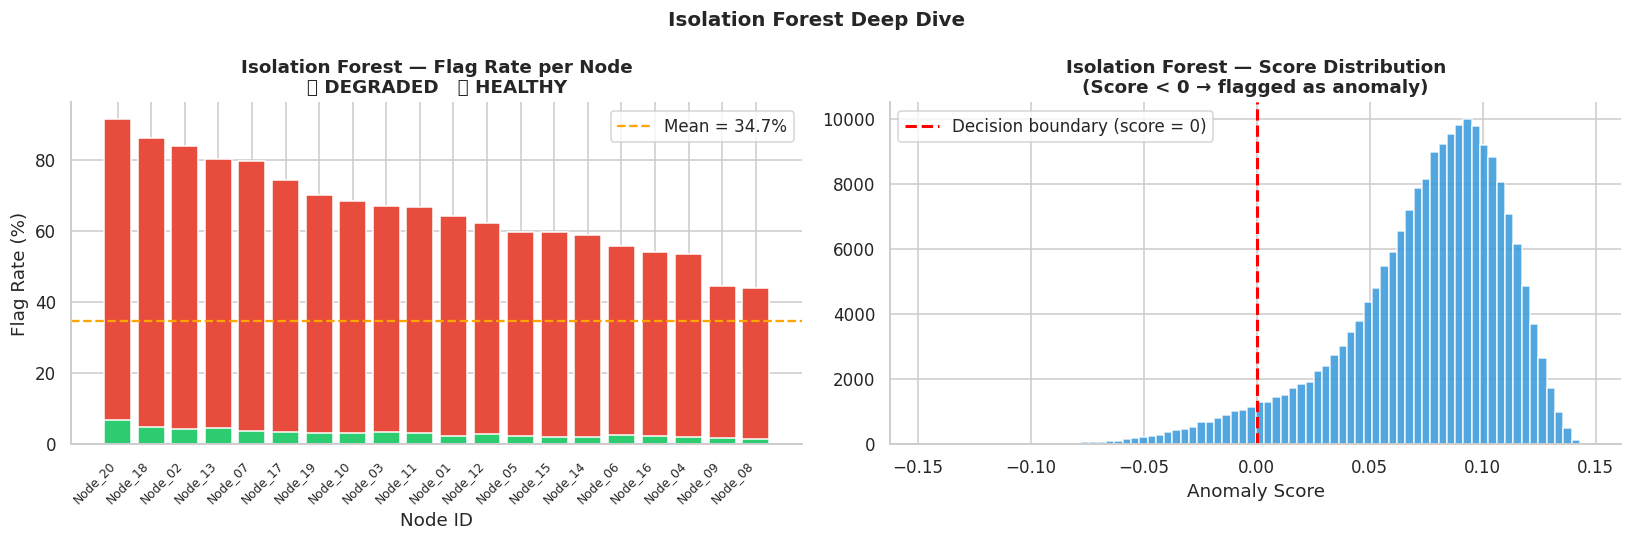


Top 5 most-flagged nodes:
node_id node_status  flags  flag_rate
Node_20    DEGRADED    283      91.59
Node_18    DEGRADED    275      86.21
Node_02    DEGRADED    281      83.88
Node_13    DEGRADED    246      80.13
Node_07    DEGRADED    245      79.55


In [35]:
iso        = IsolationForest(n_estimators=200, contamination=0.05, n_jobs=-1, random_state=42)
iso.fit(X_scaled)
iso_preds  = iso.predict(X_scaled)
iso_scores = iso.decision_function(X_scaled)

df["iso_flag"]  = (iso_preds == -1).astype(int)
df["iso_score"] = iso_scores

flagged = df["iso_flag"].sum()
print(f"Total flagged: {flagged:,}  ({flagged / len(df) * 100:.2f}%)")

by_node = (df.groupby(["node_id", "node_status"])["iso_flag"]
             .agg(flags="sum", flag_rate="mean")
             .reset_index())
by_node["flag_rate"] = (by_node["flag_rate"] * 100).round(2)
by_node = by_node.sort_values("flag_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Flag rate per node
bar_colors = ["#e74c3c" if s == "DEGRADED" else "#2ecc71" for s in by_node["node_status"]]
axes[0].bar(by_node["node_id"], by_node["flag_rate"], color=bar_colors, edgecolor="white")
axes[0].axhline(by_node["flag_rate"].mean(), color="orange", linestyle="--",
                linewidth=1.5, label=f"Mean = {by_node['flag_rate'].mean():.1f}%")
axes[0].set_title("Isolation Forest — Flag Rate per Node\n🔴 DEGRADED   🟢 HEALTHY", fontweight="bold")
axes[0].set_xlabel("Node ID")
axes[0].set_ylabel("Flag Rate (%)")
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Score distribution
axes[1].hist(iso_scores, bins=80, color="#3498db", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Decision boundary (score = 0)")
axes[1].set_title("Isolation Forest — Score Distribution\n(Score < 0 → flagged as anomaly)", fontweight="bold")
axes[1].set_xlabel("Anomaly Score")
axes[1].legend()

plt.suptitle("Isolation Forest Deep Dive", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 5 most-flagged nodes:")
print(by_node.head(5).to_string(index=False))

---
# Part D — Cross-Validation & Final Leaderboard

5-fold cross-validation splits data into 5 equal parts, trains on 4, tests on 1, and repeats 5 times. This gives a more reliable performance estimate than a single train/test split — we also get a standard deviation that shows how stable the model is.

### 5-Fold Cross-Validation

In [ ]:
top_reg_cv = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42),
    "XGBoost"           : XGBRegressor(n_estimators=50, tree_method="hist", random_state=42, verbosity=0),
    "LightGBM"          : LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=50, random_state=42),
}

print("5-Fold CV — Regression (R²)")
print(f"{'Model':<22} {'Mean R²':>9} {'Std':>9}")
print("-" * 43)
cv_reg = []
for name, model in top_reg_cv.items():
    cv = cross_val_score(model, X_scaled, y_reg, cv=5, scoring="r2", n_jobs=-1)
    cv_reg.append({"Model": name, "CV Mean R²": round(cv.mean(), 4), "CV Std": round(cv.std(), 4)})
    print(f"{name:<22} {cv.mean():>9.4f} {cv.std():>9.4f}")

top_cls_cv = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=500),
    "Random Forest"      : RandomForestClassifier(n_estimators=50, class_weight="balanced", n_jobs=-1, random_state=42),
    "XGBoost"            : XGBClassifier(n_estimators=50, tree_method="hist", random_state=42, verbosity=0),
    "LightGBM"           : LGBMClassifier(n_estimators=50, class_weight="balanced", random_state=42, verbose=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=50, random_state=42),
}

print("\n5-Fold CV — Classification (ROC-AUC)")
print(f"{'Model':<22} {'Mean AUC':>9} {'Std':>9}")
print("-" * 43)
cv_cls = []
for name, model in top_cls_cv.items():
    cv = cross_val_score(model, X_scaled, y_cls, cv=5, scoring="roc_auc", n_jobs=-1)
    cv_cls.append({"Model": name, "CV Mean AUC": round(cv.mean(), 4), "CV Std": round(cv.std(), 4)})
    print(f"{name:<22} {cv.mean():>9.4f} {cv.std():>9.4f}")

5-Fold CV — Regression (R²)
Model                    Mean R²       Std
-------------------------------------------
Linear Regression         1.0000    0.0000
